ENVIRONMENT SETUP AND DATA LOADING

In [16]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df = pd.read_csv('Advertising[1].csv')

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print("              DATA HEAD             ")
print(df.head())

              DATA HEAD             
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9


EXPLORATORY DATA ANALYSIS (EDA) AND CLEANING


In [17]:
print("         MISSSING VALUES CHECK     ")
print(df.isnull().sum())

print("\n      DATA TYPES & INFO        ")
print(df.info())

print("\n      STATISTICAL SUMMARY     ")
print(df.describe())

         MISSSING VALUES CHECK     
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

      DATA TYPES & INFO        
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

      STATISTICAL SUMMARY     
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max  

Graphs


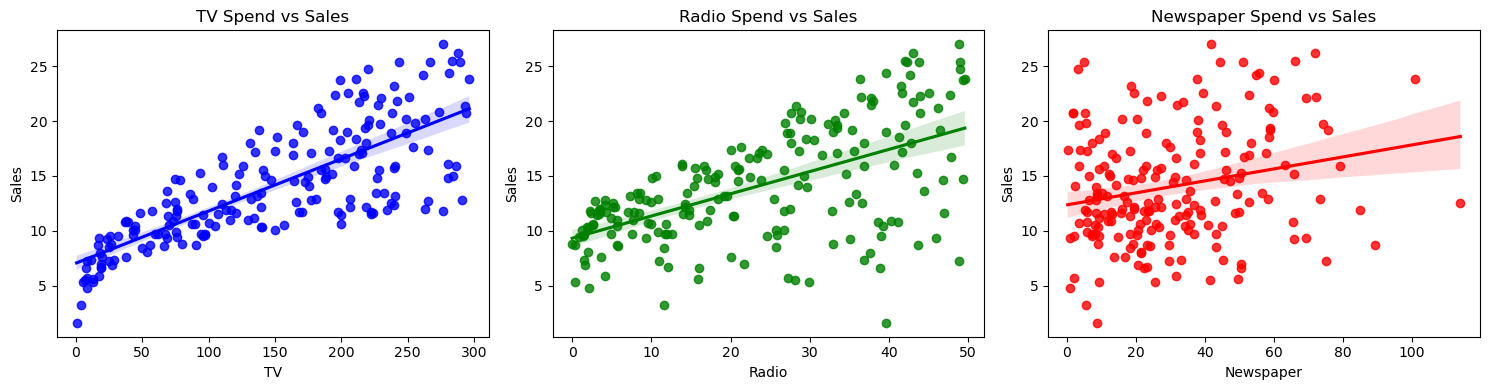

In [21]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
sns.regplot(data=df, x='TV', y='Sales', ax=axs[0], color='blue')
axs[0].set_title('TV Spend vs Sales')

sns.regplot(data=df, x='Radio', y='Sales', ax=axs[1], color='green')
axs[1].set_title('Radio Spend vs Sales')

sns.regplot(data=df, x='Newspaper', y='Sales', ax=axs[2], color='red')
axs[2].set_title('Newspaper Spend vs Sales')

plt.tight_layout()
plt.show()



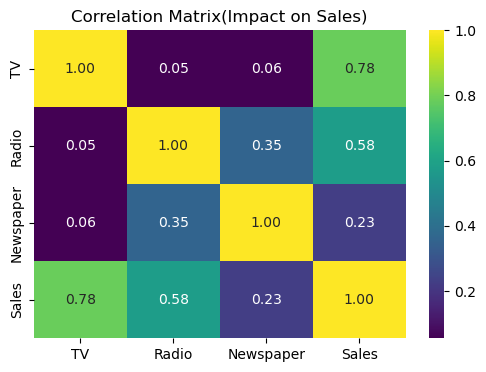

In [22]:
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='viridis', fmt=".2f")
plt.title('Correlation Matrix(Impact on Sales)')
plt.show()

FUTURE SELECTION AND DATA SPLITTING

In [23]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total rows in orginal data: {X.shape[0]}")
print(f"Rows in Traininig data (80%): {X_train.shape[0]}")
print(f"Rows in Testing data (20%): {X_test.shape[0]}")

Total rows in orginal data: 200
Rows in Traininig data (80%): 160
Rows in Testing data (20%): 40


MODEL TRAINING (LINEAR REGRESSION) & MODEL EVALUATION 

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)
print("Model is successfully trained!")


Model is successfully trained!


In [29]:
reg_model = LinearRegression()

reg_model.fit(X_train, y_train)

y_pred = reg_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("   MODEL PERFORMANCE METRICS   ")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score (Accuracy): {r2 * 100:.2f}%")

   MODEL PERFORMANCE METRICS   
Mean Absolute Error (MAE): 1.46
Mean Squared Error (MSE): 3.17
R-squared Score (Accuracy): 89.94%


BUSINESS INSIGHTS

In [32]:

insights = pd.DataFrame(reg_model.coef_, X.columns, columns=['Coefficient Impact'])
print("      BUSINESS MARKETING STRATEGY INSIGHTS     ")
print(insights.sort_values(by='Coefficient Impact', ascending=False))

print("\n     SAMPLE FORECASTING (Actual vs Predicted)     ")
pred_comparison = pd.DataFrame({'Actual Sales': y_test, 'Predicted Sales': y_pred.round(2)})
print(pred_comparison.head(10))

      BUSINESS MARKETING STRATEGY INSIGHTS     
           Coefficient Impact
Radio                0.189195
TV                   0.044730
Newspaper            0.002761

     SAMPLE FORECASTING (Actual vs Predicted)     
     Actual Sales  Predicted Sales
95           16.9            16.41
15           22.4            20.89
30           21.4            21.55
158           7.3            10.61
128          24.7            22.11
115          12.6            13.11
69           22.3            21.06
170           8.4             7.46
174          11.5            13.61
45           14.9            15.16
